# Joint Regression v3 — retrain on k_max-FIXED dataset

Identical pipeline to `joint_regression_v2.ipynb`, but trained on the dataset
regenerated **after** fixing the pyFC `k_max` bug
(`docs/bugs/pyfc-kmax-not-enforced.md`).

**What changed vs v2:**
- `DATA_FILE` -> `data/raw/balanced_4param_128x128_100000_kmaxfix.h5`
  (k_max is now a real band-limiting parameter, not a phantom label).
- `OUTPUT_DIR` -> `outputs/comparison/joint_regression_v3` (keeps the v2
  broken-data baseline intact for comparison).

**Why:** on the old (broken) data k_max was barely encoded, capping the CNN at
k_max R2 ~ 0.70 while k_min ~ 0.998 and sigma ~ 0.989. With the fix, k_max is
sharply recoverable (pilot: classical k_max R2 ~ 0.98), so retraining here should
lift k_max markedly.

**To run:** execute top-to-bottom. The training cell auto-skips if
`outputs/comparison/joint_regression_v3/results.json` already exists -- delete it
to force a fresh run. After training, re-run
`notebooks/comparison/synthetic_validation.ipynb` against the v3 checkpoint to
re-measure k_max (classical band-edge will now also recover k_max).


# Joint Regression v2 — k_min, k_max, sigma, beta (4-output)

Successor to `joint_regression.ipynb`. Trains a single ResNet50 to predict **four** continuous fractal parameters jointly.

**What is different from v1:**

- **New balanced dataset** `data/raw/balanced_4param_128x128_100000.h5` — joint-uniform rejection sampling over `(k_min, k_max)`, all four parameters sampled as **continuous floats** (no integer casting). Beta is **varied** for the first time (was fixed at −5/3 in every previous run).
- **4-output regression head** (k_min, k_max, sigma, beta).
- Same global p1/p99 image normalization (preserves the sigma signal). Same architecture, optimizer, scheduler, loss — only the data and the head changed, so any improvement we see is attributable to data balancing + adding beta.

**Dataset is generated by `scripts/run_generation_balanced.py`** (run separately). This notebook only consumes it.

**Sampling ranges:**

| Parameter | Range | Comment |
|---|---|---|
| k_min | U[1.0, 62.0] | float |
| k_max | U[3.0, 64.0] | float, joint rejection with `k_max > k_min + 2` |
| sigma | U[0.01, 5.0] | log-scaled for target normalization |
| beta | U[−3.0, −1.0] | covers Kolmogorov (−5/3), Burgers (−2), Kraichnan-edge (−3) |

In [1]:
# Cell 1 — Imports & config
from pathlib import Path
import json, time, sys
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import multiprocessing as mp

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / 'src'))
sys.path.insert(0, str(PROJECT_ROOT / 'src' / 'pyFC_lib'))

DATA_FILE  = PROJECT_ROOT / 'data' / 'raw' / 'balanced_4param_128x128_100000_kmaxfix.h5'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'comparison' / 'joint_regression_v3'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED        = 42
IMG_SIZE    = 128
EPOCHS      = 50
BATCH_SIZE  = 32
LR          = 1e-4
NUM_WORKERS = max(1, mp.cpu_count() - 1)

# Target normalisation ranges (must match the dataset's sampling ranges)
KMIN_LO, KMIN_HI = 1.0,  62.0
KMAX_LO, KMAX_HI = 3.0,  64.0
LOG_SIG_LO = float(np.log(0.01))
LOG_SIG_HI = float(np.log(5.0))
BETA_LO, BETA_HI = -3.0, -1.0

TARGET_NAMES = ['k_min', 'k_max', 'sigma', 'beta']
N_TARGETS    = len(TARGET_NAMES)

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Project: {PROJECT_ROOT}')
print(f'Data:    {DATA_FILE}')
print(f'Output:  {OUTPUT_DIR}')
print(f'Device:  {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU:     {torch.cuda.get_device_name(0)}')
print(f'Targets: {TARGET_NAMES}')

Project: c:\Users\sedig\Documents\cnn_astro
Data:    c:\Users\sedig\Documents\cnn_astro\data\raw\balanced_4param_128x128_100000_kmaxfix.h5
Output:  c:\Users\sedig\Documents\cnn_astro\outputs\comparison\joint_regression_v3
Device:  cuda
GPU:     NVIDIA GeForce RTX 3050 Ti Laptop GPU
Targets: ['k_min', 'k_max', 'sigma', 'beta']


## Cell 2 — Verify dataset

Confirms the new dataset exists, that all four parameters are continuous (have decimals), and that the joint `(k_min, k_max)` coverage is uniform on the valid region.

N = 100,000
k_min : [1.000, 61.612]  mean=21.30  decimals=True
k_max : [3.226, 64.000]  mean=43.60  decimals=True
sigma : [0.010, 5.000]  mean=2.502  decimals=True
beta  : [-3.000, -1.000]  mean=-2.001  decimals=True

k_min/k_max correlation: 0.499
k_min/beta correlation:  0.001
k_max/beta correlation:  -0.004


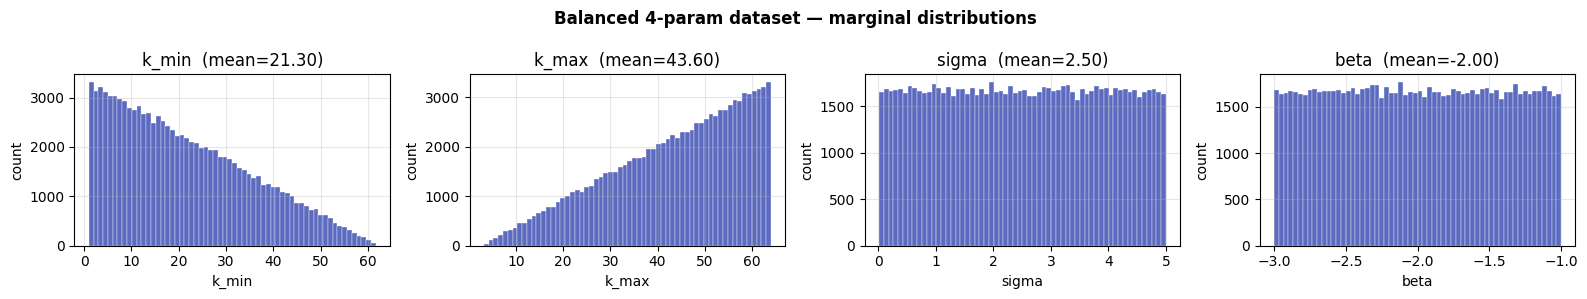

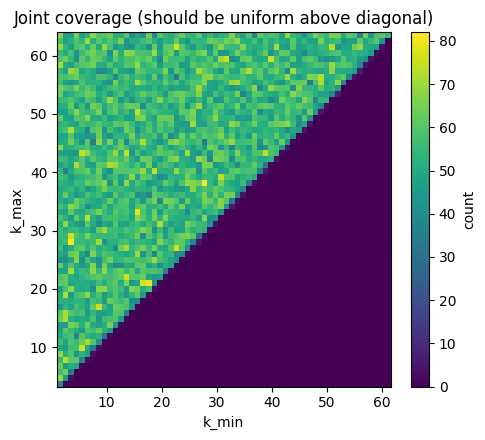

In [2]:
# Cell 2 — Verify dataset
assert DATA_FILE.exists(), (
    f'Missing dataset: {DATA_FILE}\n'
    f'Generate it first with:\n'
    f'  ~/.uve/py311/bin/python scripts/run_generation_balanced.py'
)

with h5py.File(DATA_FILE, 'r') as hf:
    n_total = hf['images'].shape[0]
    kmin  = hf['parameters']['k_min'][:]
    kmax  = hf['parameters']['k_max'][:]
    sigma = hf['parameters']['sigma'][:]
    beta  = hf['parameters']['beta'][:]

def _has_decimals(a):
    return bool(np.any(a != np.floor(a)))

print(f'N = {n_total:,}')
print(f'k_min : [{kmin.min():.3f}, {kmin.max():.3f}]  mean={kmin.mean():.2f}  decimals={_has_decimals(kmin)}')
print(f'k_max : [{kmax.min():.3f}, {kmax.max():.3f}]  mean={kmax.mean():.2f}  decimals={_has_decimals(kmax)}')
print(f'sigma : [{sigma.min():.3f}, {sigma.max():.3f}]  mean={sigma.mean():.3f}  decimals={_has_decimals(sigma)}')
print(f'beta  : [{beta.min():.3f}, {beta.max():.3f}]  mean={beta.mean():.3f}  decimals={_has_decimals(beta)}')
print(f'\nk_min/k_max correlation: {np.corrcoef(kmin, kmax)[0,1]:.3f}')
print(f'k_min/beta correlation:  {np.corrcoef(kmin, beta)[0,1]:.3f}')
print(f'k_max/beta correlation:  {np.corrcoef(kmax, beta)[0,1]:.3f}')

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, vals, label in zip(axes, [kmin, kmax, sigma, beta], TARGET_NAMES):
    ax.hist(vals, bins=60, edgecolor='white', linewidth=0.3, color='#3F51B5', alpha=0.85)
    ax.set_xlabel(label); ax.set_ylabel('count')
    ax.set_title(f'{label}  (mean={vals.mean():.2f})')
    ax.grid(True, alpha=0.3)
plt.suptitle('Balanced 4-param dataset — marginal distributions', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dataset_marginals.png', dpi=120, bbox_inches='tight')
plt.show()

# 2D coverage: (k_min, k_max)
fig, ax = plt.subplots(figsize=(5, 4.5))
h, xe, ye, im = ax.hist2d(kmin, kmax, bins=60, cmap='viridis')
ax.set_xlabel('k_min'); ax.set_ylabel('k_max')
ax.set_title('Joint coverage (should be uniform above diagonal)')
plt.colorbar(im, ax=ax, label='count')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dataset_kmin_kmax_joint.png', dpi=120, bbox_inches='tight')
plt.show()

In [3]:
# Cell 3 — Global image percentiles (computed once from a 2K subsample)
np.random.seed(SEED)
samp_size = 2000

with h5py.File(DATA_FILE, 'r') as hf:
    samp_idx = np.sort(np.random.choice(n_total, size=samp_size, replace=False))
    samp = hf['images'][samp_idx]

IMG_P1  = float(np.percentile(samp, 1))
IMG_P99 = float(np.percentile(samp, 99))
del samp

print(f'Global image percentiles:  p1={IMG_P1:.4f}  p99={IMG_P99:.4f}')
print(f'(v1 reference for sanity:  p1=-2.0818  p99=0.9409)')

Global image percentiles:  p1=-2.0862  p99=0.9465
(v1 reference for sanity:  p1=-2.0818  p99=0.9409)


In [4]:
# Cell 4 — Dataset & splits (4-target)

class JointHDF5Dataset4(Dataset):
    """
    Loads images with global p1/p99 normalisation (preserves sigma contrast).
    Returns labels as (4,) tensor: [k_min_n, k_max_n, log_sigma_n, beta_n] in [0,1].
    """
    def __init__(self, h5_path, indices, kmin_v, kmax_v, sigma_v, beta_v,
                 img_p1, img_p99):
        self.h5_path   = str(h5_path)
        self.indices   = indices
        self.img_p1    = float(img_p1)
        self.img_range = float(img_p99 - img_p1) + 1e-8

        kmin_n = (kmin_v[indices] - KMIN_LO) / (KMIN_HI - KMIN_LO)
        kmax_n = (kmax_v[indices] - KMAX_LO) / (KMAX_HI - KMAX_LO)
        log_sig = np.log(np.clip(sigma_v[indices].astype(np.float64), 1e-9, None))
        sig_n  = (log_sig - LOG_SIG_LO) / (LOG_SIG_HI - LOG_SIG_LO)
        beta_n = (beta_v[indices] - BETA_LO) / (BETA_HI - BETA_LO)

        self.labels = np.stack([kmin_n, kmax_n, sig_n, beta_n], axis=1).astype(np.float32)
        self._h5 = None

    def _get_h5(self):
        if self._h5 is None:
            self._h5 = h5py.File(self.h5_path, 'r')
        return self._h5

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img = self._get_h5()['images'][self.indices[idx]].astype(np.float32)
        img = (img - self.img_p1) / self.img_range
        img = img[np.newaxis]
        return torch.from_numpy(img), torch.from_numpy(self.labels[idx])

    def __del__(self):
        if self._h5 is not None:
            self._h5.close()


indices = np.arange(n_total)
train_idx, tmp = train_test_split(indices, test_size=0.2, random_state=SEED)
val_idx, test_idx = train_test_split(tmp,    test_size=0.5, random_state=SEED)

ds_kw = dict(kmin_v=kmin, kmax_v=kmax, sigma_v=sigma, beta_v=beta,
             img_p1=IMG_P1, img_p99=IMG_P99)
train_ds = JointHDF5Dataset4(DATA_FILE, train_idx, **ds_kw)
val_ds   = JointHDF5Dataset4(DATA_FILE, val_idx,   **ds_kw)
test_ds  = JointHDF5Dataset4(DATA_FILE, test_idx,  **ds_kw)

loader_kw = dict(batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
train_loader = DataLoader(train_ds, shuffle=True,  **loader_kw)
val_loader   = DataLoader(val_ds,   shuffle=False, **loader_kw)
test_loader  = DataLoader(test_ds,  shuffle=False, **loader_kw)

print(f'Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}')

Train: 80,000  Val: 10,000  Test: 10,000


In [5]:
# Cell 5 — ResNet50 with 4-output Sigmoid head

class ResNet50Joint4(nn.Module):
    def __init__(self, in_channels=1, n_outputs=N_TARGETS):
        super().__init__()
        self.backbone = models.resnet50(weights=None)
        self.backbone.conv1 = nn.Conv2d(
            in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        in_feats = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_feats, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 64),       nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, n_outputs),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.backbone(x)

n_params = sum(p.numel() for p in ResNet50Joint4().parameters())
print(f'ResNet50Joint4 params: {n_params:,}')

ResNet50Joint4 params: 24,043,012


In [6]:
# Cell 6 — Joint RMSE loss, train/eval helpers, denorm (4-target)

class JointRMSELoss(nn.Module):
    """Sum of per-output RMSE on normalised [0,1] targets (equal weight)."""
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps
    def forward(self, pred, target):
        diff = pred - target
        mse  = diff.pow(2).mean(dim=0)
        return torch.sqrt(mse + self.eps).sum()


def train_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    total = 0.0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        if scaler:
            with torch.amp.autocast('cuda'):
                loss = criterion(model(X), y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
        total += loss.item() * len(X)
    return total / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total, preds, targets = 0.0, [], []
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        total += criterion(pred, y).item() * len(X)
        preds.append(pred.cpu())
        targets.append(y.cpu())
    preds   = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()
    mae_per_output = np.mean(np.abs(preds - targets), axis=0)
    return total / len(loader.dataset), mae_per_output, preds, targets


def denorm(preds_n, targets_n):
    """Map normalised [0,1] back to physical units. Sigma uses log-scale denorm."""
    def _back(col, lo, hi):
        return col * (hi - lo) + lo
    p = {
        'k_min': _back(preds_n[:, 0],  KMIN_LO,    KMIN_HI),
        'k_max': _back(preds_n[:, 1],  KMAX_LO,    KMAX_HI),
        'sigma': np.exp(_back(preds_n[:, 2], LOG_SIG_LO, LOG_SIG_HI)),
        'beta':  _back(preds_n[:, 3],  BETA_LO,    BETA_HI),
    }
    t = {
        'k_min': _back(targets_n[:, 0], KMIN_LO,    KMIN_HI),
        'k_max': _back(targets_n[:, 1], KMAX_LO,    KMAX_HI),
        'sigma': np.exp(_back(targets_n[:, 2], LOG_SIG_LO, LOG_SIG_HI)),
        'beta':  _back(targets_n[:, 3], BETA_LO,    BETA_HI),
    }
    return p, t

print('Loss, helpers, and denorm defined.')

Loss, helpers, and denorm defined.


In [7]:
# Cell 7 — Smoke test: 2K images, 5 epochs (sanity check before full run)
from torch.utils.data import Subset

SMOKE_TRAIN, SMOKE_VAL, SMOKE_TEST, SMOKE_EPOCHS = 2000, 500, 500, 5

rng = np.random.RandomState(SEED)
smoke_train_ds = Subset(train_ds, rng.choice(len(train_ds), SMOKE_TRAIN, replace=False))
smoke_val_ds   = Subset(val_ds,   rng.choice(len(val_ds),   SMOKE_VAL,   replace=False))
smoke_test_ds  = Subset(test_ds,  rng.choice(len(test_ds),  SMOKE_TEST,  replace=False))

skw = dict(batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
smoke_train_loader = DataLoader(smoke_train_ds, shuffle=True,  **skw)
smoke_val_loader   = DataLoader(smoke_val_ds,   shuffle=False, **skw)
smoke_test_loader  = DataLoader(smoke_test_ds,  shuffle=False, **skw)

smoke_model     = ResNet50Joint4(in_channels=1).to(DEVICE)
smoke_criterion = JointRMSELoss().to(DEVICE)
smoke_optimizer = optim.AdamW(smoke_model.parameters(), lr=LR, weight_decay=1e-4)
smoke_scaler    = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None

print(f'Smoke: {SMOKE_TRAIN} train / {SMOKE_VAL} val / {SMOKE_TEST} test  |  {SMOKE_EPOCHS} epochs')
t0 = time.time()
for ep in range(SMOKE_EPOCHS):
    tl = train_epoch(smoke_model, smoke_train_loader, smoke_criterion, smoke_optimizer, smoke_scaler, DEVICE)
    vl, vm, _, _ = eval_epoch(smoke_model, smoke_val_loader, smoke_criterion, DEVICE)
    print(f'  Ep {ep+1}/{SMOKE_EPOCHS} | train {tl:.4f} | val {vl:.4f}'
          f' | mae kmin={vm[0]:.4f} kmax={vm[1]:.4f} sig={vm[2]:.4f} beta={vm[3]:.4f}')
ep_time = (time.time() - t0) / SMOKE_EPOCHS
print(f'\nTime per epoch (smoke): {ep_time:.1f}s')
print(f'Est. full ({EPOCHS} ep × {len(train_ds):,}): '
      f'~{ep_time * EPOCHS * len(train_ds) / SMOKE_TRAIN / 60:.0f} min')

_, _, sp, st = eval_epoch(smoke_model, smoke_test_loader, smoke_criterion, DEVICE)
sp_d, st_d = denorm(sp, st)
print('\n--- Smoke test (physical units) ---')
for p in TARGET_NAMES:
    print(f'  {p:<6}  MAE={mean_absolute_error(st_d[p], sp_d[p]):.3f}  '
          f'R²={r2_score(st_d[p], sp_d[p]):.4f}')

del smoke_model, smoke_optimizer, smoke_scaler
if torch.cuda.is_available(): torch.cuda.empty_cache()

Smoke: 2000 train / 500 val / 500 test  |  5 epochs
  Ep 1/5 | train 0.8740 | val 0.7281 | mae kmin=0.1244 kmax=0.1834 sig=0.0583 beta=0.2493
  Ep 2/5 | train 0.7056 | val 0.6271 | mae kmin=0.0533 kmax=0.1640 sig=0.0495 beta=0.2526
  Ep 3/5 | train 0.6776 | val 0.6020 | mae kmin=0.0491 kmax=0.1639 sig=0.0254 beta=0.2506
  Ep 4/5 | train 0.6512 | val 0.6156 | mae kmin=0.0649 kmax=0.1637 sig=0.0287 beta=0.2496
  Ep 5/5 | train 0.6474 | val 0.5859 | mae kmin=0.0463 kmax=0.1592 sig=0.0259 beta=0.2494

Time per epoch (smoke): 8.3s
Est. full (50 ep × 80,000): ~277 min

--- Smoke test (physical units) ---
  k_min   MAE=2.795  R²=0.9257
  k_max   MAE=10.126  R²=0.2150
  sigma   MAE=0.318  R²=0.9063
  beta    MAE=0.497  R²=0.0083


In [8]:
# Cell 8 — Full training loop (resume-safe: skips if results.json exists)
results_path = OUTPUT_DIR / 'results.json'
best_ckpt    = OUTPUT_DIR / 'best_model.pt'

if results_path.exists():
    print(f'[SKIP] {results_path.name} already exists — jump to evaluation cells.')
else:
    model     = ResNet50Joint4(in_channels=1).to(DEVICE)
    criterion = JointRMSELoss().to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-7)
    scaler    = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None

    history = {'train_loss': [], 'val_loss': []}
    for t in TARGET_NAMES:
        history[f'val_mae_{t}'] = []
    best_val_loss = float('inf')
    run_start = time.time()

    for epoch in range(EPOCHS):
        tl = train_epoch(model, train_loader, criterion, optimizer, scaler, DEVICE)
        vl, val_mae, _, _ = eval_epoch(model, val_loader, criterion, DEVICE)
        scheduler.step(vl)

        history['train_loss'].append(float(tl))
        history['val_loss'].append(float(vl))
        for i, t in enumerate(TARGET_NAMES):
            history[f'val_mae_{t}'].append(float(val_mae[i]))

        lr_now = optimizer.param_groups[0]['lr']
        print(f'Ep {epoch+1:2d}/{EPOCHS} | train {tl:.4f} | val {vl:.4f} '
              f'| mae kmin={val_mae[0]:.4f} kmax={val_mae[1]:.4f} '
              f'sig={val_mae[2]:.4f} beta={val_mae[3]:.4f} | lr {lr_now:.1e}')

        if vl < best_val_loss:
            best_val_loss = vl
            torch.save(model.state_dict(), best_ckpt)

    train_time_min = (time.time() - run_start) / 60
    print(f'\nTraining done in {train_time_min:.1f} min   best val loss: {best_val_loss:.4f}')

    # Final test evaluation
    model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
    _, _, y_pred_n, y_true_n = eval_epoch(model, test_loader, criterion, DEVICE)
    y_pred_d, y_true_d = denorm(y_pred_n, y_true_n)

    metrics = {}
    for p in TARGET_NAMES:
        metrics[p] = {
            'mae':  float(mean_absolute_error(y_true_d[p], y_pred_d[p])),
            'rmse': float(np.sqrt(mean_squared_error(y_true_d[p], y_pred_d[p]))),
            'r2':   float(r2_score(y_true_d[p], y_pred_d[p])),
        }

    results = {
        'history': history,
        'metrics': metrics,
        'best_val_loss': float(best_val_loss),
        'training_time_min': float(train_time_min),
        'y_true': {p: y_true_d[p].tolist() for p in TARGET_NAMES},
        'y_pred': {p: y_pred_d[p].tolist() for p in TARGET_NAMES},
        'img_p1': IMG_P1, 'img_p99': IMG_P99,
    }
    with open(results_path, 'w') as f:
        json.dump(results, f)
    print(f'Saved: {results_path}')

Ep  1/50 | train 0.6295 | val 0.5368 | mae kmin=0.0290 kmax=0.1467 sig=0.0273 beta=0.2341 | lr 1.0e-04
Ep  2/50 | train 0.5580 | val 0.5003 | mae kmin=0.0259 kmax=0.1282 sig=0.0239 beta=0.2241 | lr 1.0e-04
Ep  3/50 | train 0.5262 | val 0.4557 | mae kmin=0.0248 kmax=0.1052 sig=0.0178 beta=0.2162 | lr 1.0e-04
Ep  4/50 | train 0.4941 | val 0.4311 | mae kmin=0.0194 kmax=0.0994 sig=0.0160 beta=0.2119 | lr 1.0e-04
Ep  5/50 | train 0.4739 | val 0.4151 | mae kmin=0.0179 kmax=0.0923 sig=0.0134 beta=0.2056 | lr 1.0e-04
Ep  6/50 | train 0.4571 | val 0.4633 | mae kmin=0.0216 kmax=0.1033 sig=0.0140 beta=0.2176 | lr 1.0e-04
Ep  7/50 | train 0.4450 | val 0.3958 | mae kmin=0.0210 kmax=0.0791 sig=0.0152 beta=0.1963 | lr 1.0e-04
Ep  8/50 | train 0.4338 | val 0.3991 | mae kmin=0.0152 kmax=0.0832 sig=0.0122 beta=0.1956 | lr 1.0e-04
Ep  9/50 | train 0.4257 | val 0.4184 | mae kmin=0.0161 kmax=0.0887 sig=0.0120 beta=0.2128 | lr 1.0e-04
Ep 10/50 | train 0.4174 | val 0.5347 | mae kmin=0.0337 kmax=0.1203 sig=0.

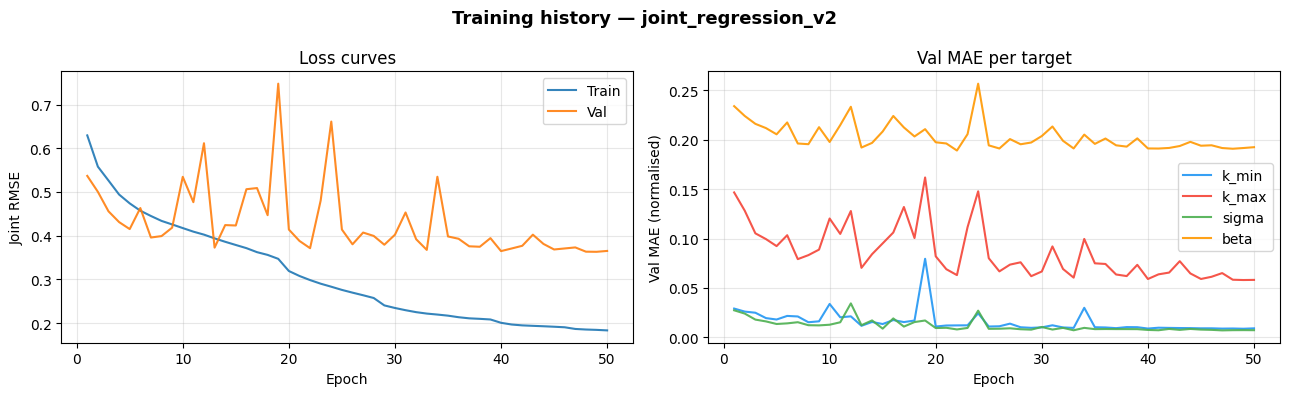

In [13]:
# Cell 9 — Load results (re-entrant) and plot training curves
if 'results' not in globals():
    with open(results_path) as f:
        results = json.load(f)
    print(f'Loaded results from {results_path}')

h = results['history']
ep_range = range(1, len(h['train_loss']) + 1)

COLORS = {'k_min': '#2196F3', 'k_max': '#F44336', 'sigma': '#4CAF50', 'beta': '#FF9800'}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ep_range, h['train_loss'], label='Train', alpha=0.9)
axes[0].plot(ep_range, h['val_loss'],   label='Val',   alpha=0.9)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Joint RMSE')
axes[0].set_title('Loss curves'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

for t in TARGET_NAMES:
    key = f'val_mae_{t}'
    if key in h:
        axes[1].plot(ep_range, h[key], label=t, color=COLORS[t], alpha=0.9)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val MAE (normalised)')
axes[1].set_title('Val MAE per target'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Training history — joint_regression_v2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

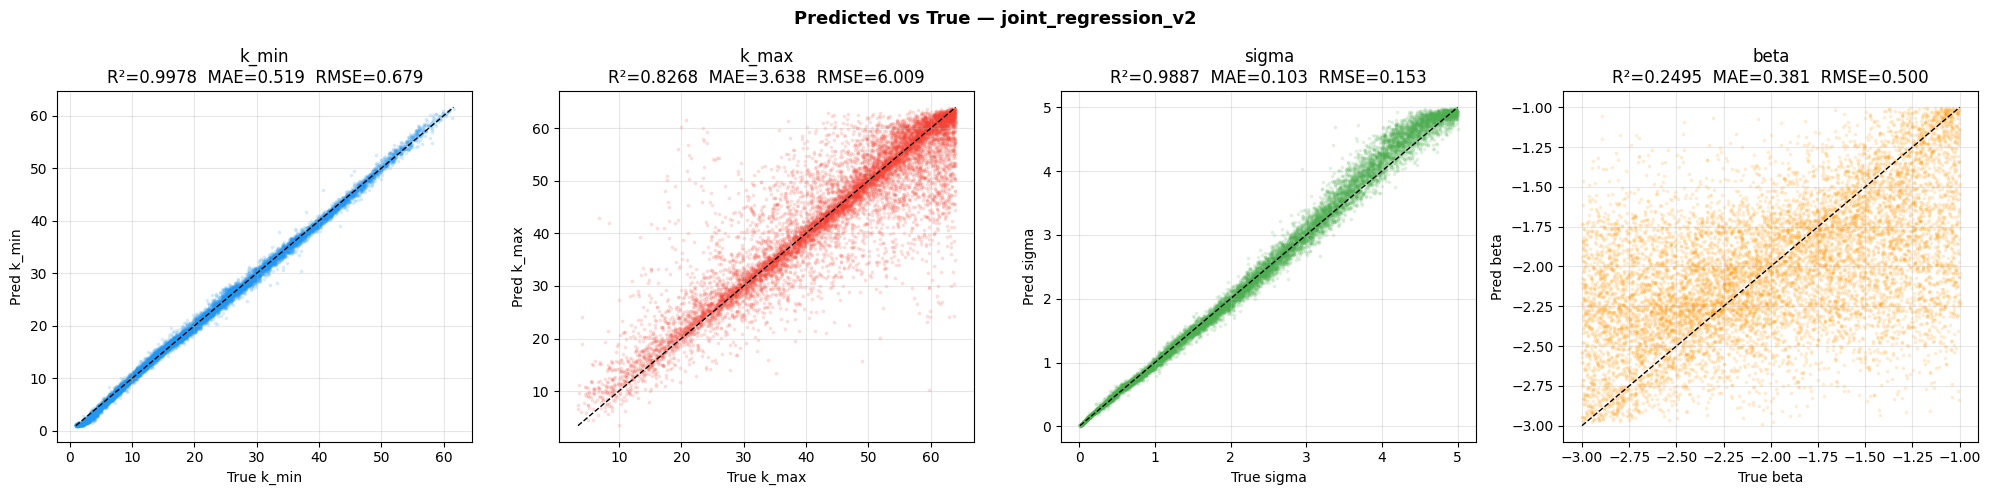

In [14]:
# Cell 10 — Predicted vs True scatter (4 panels)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, p in zip(axes, TARGET_NAMES):
    yt = np.array(results['y_true'][p])
    yp = np.array(results['y_pred'][p])
    m  = results['metrics'][p]
    ax.scatter(yt, yp, alpha=0.12, s=3, color=COLORS[p], rasterized=True)
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, 'k--', linewidth=1)
    ax.set_xlabel(f'True {p}'); ax.set_ylabel(f'Pred {p}')
    ax.set_title(f'{p}\nR²={m["r2"]:.4f}  MAE={m["mae"]:.3f}  RMSE={m["rmse"]:.3f}')
    ax.grid(True, alpha=0.3)
plt.suptitle('Predicted vs True — joint_regression_v2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scatter.png', dpi=150, bbox_inches='tight')
plt.show()

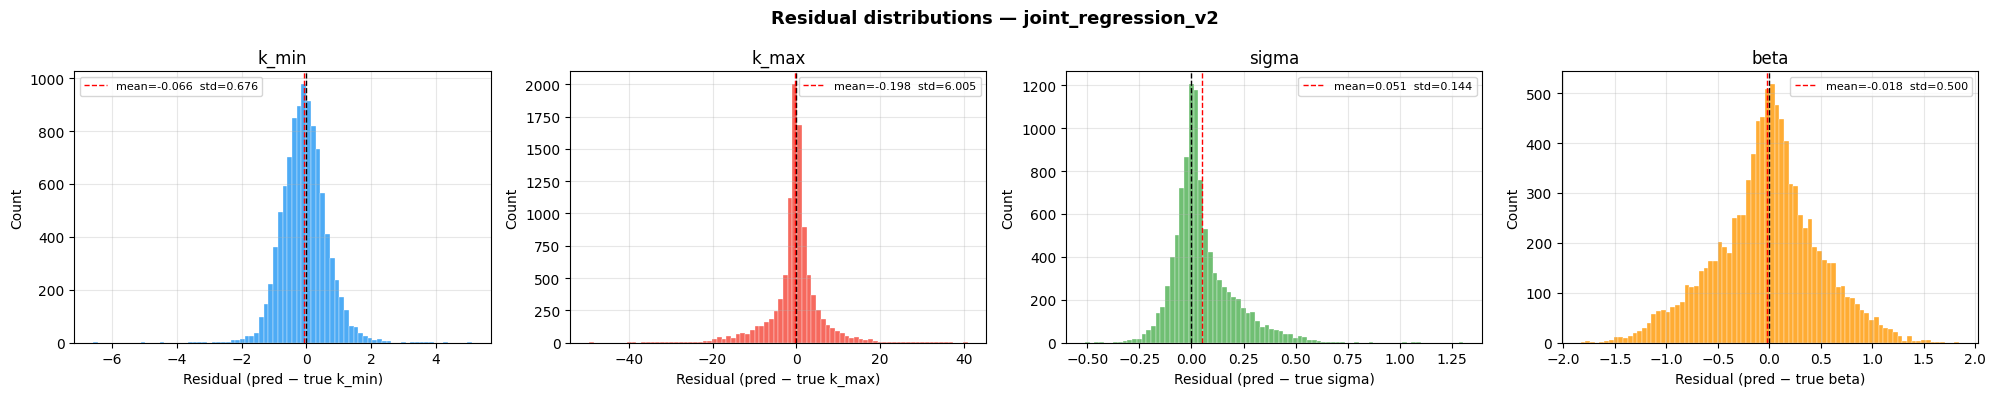

In [15]:
# Cell 11 — Residual distributions
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, p in zip(axes, TARGET_NAMES):
    yt = np.array(results['y_true'][p]); yp = np.array(results['y_pred'][p])
    res = yp - yt
    ax.hist(res, bins=80, color=COLORS[p], alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.axvline(res.mean(), color='red', linestyle='--', linewidth=1,
               label=f'mean={res.mean():.3f}  std={res.std():.3f}')
    ax.set_xlabel(f'Residual (pred − true {p})')
    ax.set_ylabel('Count'); ax.set_title(p)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle('Residual distributions — joint_regression_v2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'residuals.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Cell 12 — Summary table + delta vs v1
V1_METRICS = {
    'k_min': {'mae': 0.475, 'rmse': 0.641, 'r2': 0.9987},
    'k_max': {'mae': 3.917, 'rmse': 6.747, 'r2': 0.7597},
    'sigma': {'mae': 0.080, 'rmse': 0.114, 'r2': 0.9937},
}

print(f"\n{'='*70}")
print('joint_regression_v2 — test set performance')
print(f'Dataset: {DATA_FILE.name}')
tt = results.get('training_time_min')
if tt: print(f'Training time: {tt:.1f} min')
print('='*70)
print(f"{'PARAM':<8} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'Δ MAE vs v1':>14} {'Δ R² vs v1':>12}")
print('-'*70)
for p in TARGET_NAMES:
    m = results['metrics'][p]
    if p in V1_METRICS:
        dmae = m['mae'] - V1_METRICS[p]['mae']
        dr2  = m['r2']  - V1_METRICS[p]['r2']
        print(f"{p:<8} {m['mae']:>8.3f} {m['rmse']:>8.3f} {m['r2']:>8.4f} "
              f"{dmae:>+14.3f} {dr2:>+12.4f}")
    else:
        print(f"{p:<8} {m['mae']:>8.3f} {m['rmse']:>8.3f} {m['r2']:>8.4f} {'(new)':>14} {'(new)':>12}")
print('='*70)

ranges = {
    'k_min': KMIN_HI - KMIN_LO,
    'k_max': KMAX_HI - KMAX_LO,
    'sigma': np.exp(LOG_SIG_HI) - np.exp(LOG_SIG_LO),
    'beta':  BETA_HI - BETA_LO,
}
print('\nMAE as % of parameter range:')
for p in TARGET_NAMES:
    pct = 100 * results['metrics'][p]['mae'] / ranges[p]
    print(f'  {p:<6}  {pct:.2f}%')


joint_regression_v2 — test set performance
Dataset: balanced_4param_128x128_100000_kmaxfix.h5
Training time: 274.8 min
PARAM         MAE     RMSE       R²    Δ MAE vs v1   Δ R² vs v1
----------------------------------------------------------------------
k_min       0.519    0.679   0.9978         +0.044      -0.0009
k_max       3.638    6.009   0.8268         -0.279      +0.0671
sigma       0.103    0.153   0.9887         +0.023      -0.0050
beta        0.381    0.500   0.2495          (new)        (new)

MAE as % of parameter range:
  k_min   0.85%
  k_max   5.96%
  sigma   2.06%
  beta    19.05%
